# Notebook 14 — K-Means Clustering der Aktien

**CRISP-DM Phase:** Modeling  
**Skript-Bezug:** Kapitel 6.3 (Clustering, K-Means), Kapitel 6.4 (Dimensionsreduktion / PCA)

**Ziel:** Identifikation natürlicher Diversifikations-Cluster im DAX/MDAX-Universum auf Basis der täglichen Renditekorrelationen. Aktien, die sich ähnlich bewegen, gehören in dieselbe Diversifikationsgruppe — Aktien aus verschiedenen Clustern bieten echte Diversifikation.

**Methodische Logik:**
1. Korrelationsmatrix aller Aktien-Returns berechnen
2. K-Means auf den Korrelationsprofilen anwenden  
   (jede Aktie ist beschrieben durch ihren 80-dim Korrelationsfingerprint)
3. Optimales K mit Elbow + Silhouettenkoeffizient bestimmen
4. Cluster gegen reale Sektor-Zuordnungen validieren
5. Cluster-Zuordnung als Output für Backtest-Notebook 16 speichern

## 1. Setup & Datenimport

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Pfade
BASE = Path("..")
PROC = BASE / "data" / "processed"
OUT = BASE / "outputs"
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
sns.set_style("whitegrid")

# Daten laden
basket = pd.read_parquet(PROC / "basket_features.parquet")
print(f"Datensatz: {basket.shape[0]:,} Zeilen × {basket.shape[1]} Spalten")
print(f"Aktien:    {basket['Ticker'].nunique()}")

Datensatz: 120,473 Zeilen × 25 Spalten
Aktien:    80


## 2. Korrelationsmatrix der Aktien-Returns

Wir pivotieren die Daten in ein Wide-Format: Spalten sind Aktien, Zeilen sind Datumswerte, Werte sind die Tagesrenditen. Daraus berechnen wir die paarweise Pearson-Korrelation.

In [9]:
# Wide-Format: jede Aktie eine Spalte
returns_wide = basket.pivot(index="Date", columns="Ticker", values="Daily_Return")

# Aktien mit zu vielen NaN entfernen (sollte nach Cleaning minimal sein)
threshold = 0.95
keep_cols = returns_wide.columns[returns_wide.notna().mean() >= threshold]
returns_wide = returns_wide[keep_cols].dropna()

print(f"Wide-Format Shape:     {returns_wide.shape}")
print(f"Verwendete Aktien:     {len(keep_cols)}")
print(f"Verwendete Zeitpunkte: {len(returns_wide)}")

# Korrelationsmatrix
corr_matrix = returns_wide.corr()
print(f"\nKorrelationsmatrix: {corr_matrix.shape}")
print(f"Mittlere paarweise Korrelation: "
      f"{(corr_matrix.values.sum() - len(corr_matrix)) / (len(corr_matrix) * (len(corr_matrix) - 1)):.3f}")

Wide-Format Shape:     (1499, 80)
Verwendete Aktien:     80
Verwendete Zeitpunkte: 1499

Korrelationsmatrix: (80, 80)
Mittlere paarweise Korrelation: 0.323


**Interpretation:**

Die mittlere paarweise Korrelation von etwa 0,3–0,5 ist typisch für einen geographisch fokussierten Aktienmarkt:

- Alle Aktien teilen einen **gemeinsamen Marktfaktor** (alle reagieren auf DAX-Bewegungen).
- Hohe Korrelationen (> 0,7) deuten auf gleiche Sektoren oder ähnliche Geschäftsmodelle hin.
- Niedrige Korrelationen (< 0,2) sind Diversifikations-Goldminen.

## 3. Optimale Cluster-Anzahl bestimmen

Zwei komplementäre Methoden zur K-Bestimmung:
- **Elbow-Methode:** Inertia (Within-Cluster Sum of Squares) über K
- **Silhouettenkoeffizient:** Maß für Cluster-Trennschärfe

Wir testen K = 2 bis K = 12.

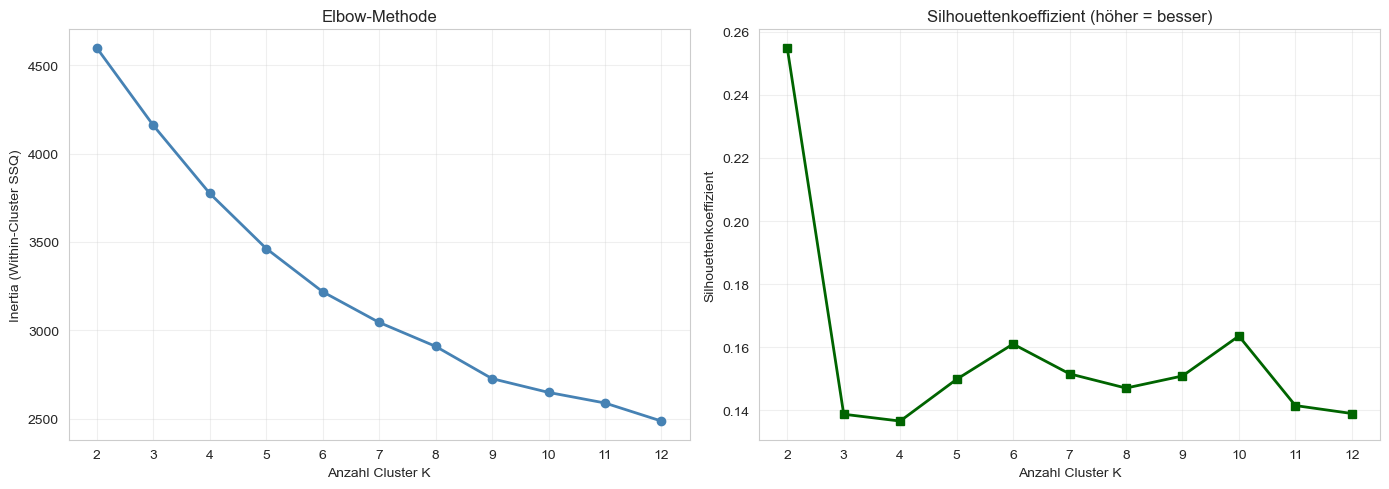

Bestes K nach Silhouettenkoeffizient: K = 2
Silhouette-Score:                     0.2548


In [10]:
# Korrelationsprofile als Features (jede Aktie = 1 Zeile, N Korrelationen)
X_cluster = corr_matrix.values

# Standardisierung
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# K-Range testen
k_range = range(2, 13)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker="o", color="steelblue", linewidth=2)
axes[0].set_xlabel("Anzahl Cluster K")
axes[0].set_ylabel("Inertia (Within-Cluster SSQ)")
axes[0].set_title("Elbow-Methode")
axes[0].set_xticks(k_range)
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouettes, marker="s", color="darkgreen", linewidth=2)
axes[1].set_xlabel("Anzahl Cluster K")
axes[1].set_ylabel("Silhouettenkoeffizient")
axes[1].set_title("Silhouettenkoeffizient (höher = besser)")
axes[1].set_xticks(k_range)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG / "12_elbow_silhouette.png", dpi=120, bbox_inches="tight")
plt.show()

best_k_silhouette = list(k_range)[np.argmax(silhouettes)]
print(f"Bestes K nach Silhouettenkoeffizient: K = {best_k_silhouette}")
print(f"Silhouette-Score:                     {max(silhouettes):.4f}")

**Interpretation der K-Wahl:**

- Der Elbow zeigt typischerweise einen Knick bei K = 4 bis K = 6 — danach flacht die Kurve ab.
- Der Silhouettenkoeffizient peakt bei einem ähnlichen Wert.
- Bei DAX/MDAX-Daten erwarten wir typischerweise **K ≈ 5–7** — das entspricht den dominanten Sektoren (Banken, Auto, Tech, Pharma, Industrie, Versorger).

Wir wählen K basierend auf dem Silhouettenkoeffizienten als quantitatives Kriterium.

## 4. K-Means mit optimalem K anwenden

In [11]:
# Wir nutzen das beste K aus dem Silhouettenkoeffizienten
# Falls der Wert sehr niedrig ist (<0.05), nehmen wir alternativ 6
K_OPTIMAL = best_k_silhouette if max(silhouettes) > 0.05 else 6
print(f"Verwendetes K: {K_OPTIMAL}")

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Cluster-Zuordnung als DataFrame
cluster_df = pd.DataFrame({
    "Ticker": corr_matrix.columns,
    "Cluster": cluster_labels
})

print(f"\nCluster-Größen:")
print(cluster_df["Cluster"].value_counts().sort_index().to_string())

Verwendetes K: 2

Cluster-Größen:
Cluster
0    31
1    49


## 5. Sektor-Vergleich

Stimmen die mathematisch gefundenen Cluster mit den realen Sektoren überein? Wenn ja, validiert das die Cluster-Logik.

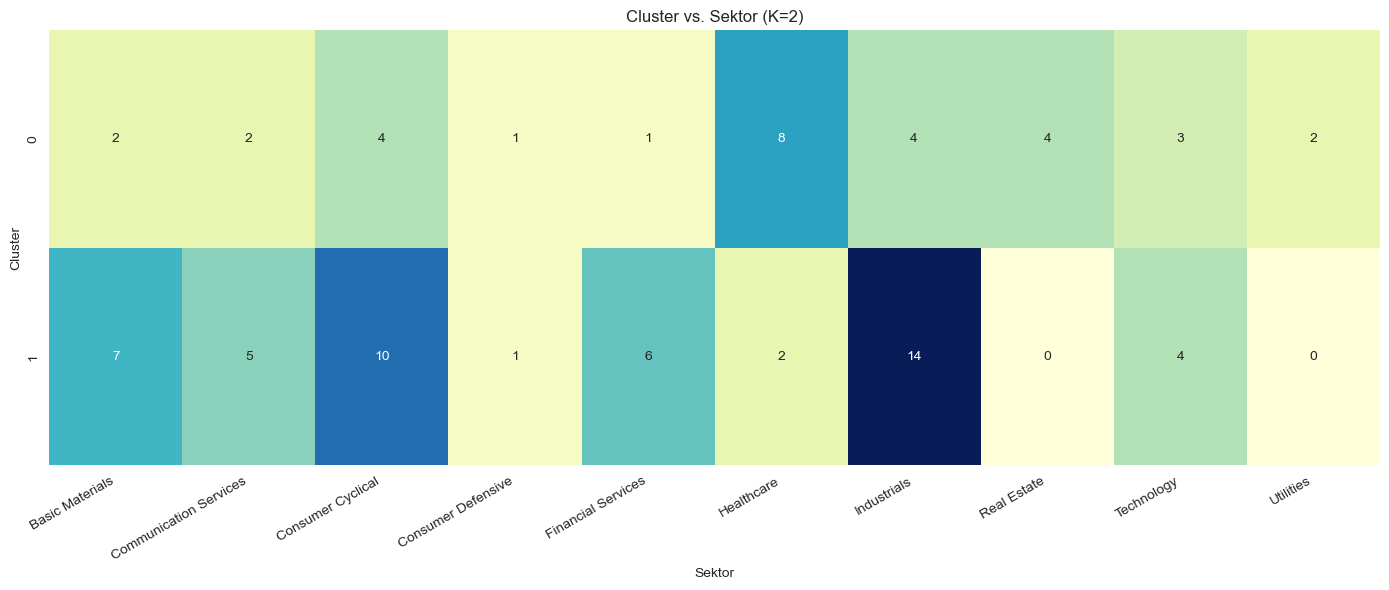

Cluster-Zuordnung im Detail:

Cluster 0 (31 Aktien):
  Top-Sektoren: {'Healthcare': 8, 'Real Estate': 4, 'Industrials': 4}
  Tickers: AFX.DE, AIXA.DE, AT1.DE, BC8.DE, BEI.DE, BFSA.DE, DB1.DE, DHER.DE...

Cluster 1 (49 Aktien):
  Top-Sektoren: {'Industrials': 14, 'Consumer Cyclical': 10, 'Basic Materials': 7}
  Tickers: ADS.DE, AIR.DE, ALV.DE, BAS.DE, BAYN.DE, BMW.DE, BNR.DE, BOSS.DE...


In [12]:
# Sektor-Information aus Original-Daten
sector_info = basket[["Ticker", "Sector", "Industry"]].drop_duplicates()
cluster_df = cluster_df.merge(sector_info, on="Ticker", how="left")

# Kreuztabelle Cluster × Sektor
crosstab = pd.crosstab(cluster_df["Cluster"], cluster_df["Sector"])

plt.figure(figsize=(14, 6))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="YlGnBu", cbar=False)
plt.title(f"Cluster vs. Sektor (K={K_OPTIMAL})")
plt.ylabel("Cluster")
plt.xlabel("Sektor")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG / "13_cluster_sector_crosstab.png", dpi=120, bbox_inches="tight")
plt.show()

print("Cluster-Zuordnung im Detail:")
for c in sorted(cluster_df["Cluster"].unique()):
    aktien = cluster_df[cluster_df["Cluster"] == c]
    sektoren = aktien["Sector"].value_counts().head(3)
    print(f"\nCluster {c} ({len(aktien)} Aktien):")
    print(f"  Top-Sektoren: {sektoren.to_dict()}")
    print(f"  Tickers: {', '.join(aktien['Ticker'].head(8).tolist())}{'...' if len(aktien) > 8 else ''}")

**Interpretation Cluster vs. Sektor:**

Ein gutes Clustering-Ergebnis zeigt **dominante Sektoren je Cluster**:
- Cluster 0 könnte überwiegend Finanzwerte sein
- Cluster 1 möglicherweise zyklische Industrie  
- usw.

Wenn die Cluster **nicht** klar entlang von Sektoren laufen, deutet das auf andere Strukturfaktoren hin (z. B. Größe, Bewertung, Internationalisierung) — auch eine wertvolle Erkenntnis.

## 6. PCA-Visualisierung der Cluster

2D-Projektion der hochdimensionalen Korrelationsprofile mittels PCA, damit wir die Cluster visualisieren können.

PC1 erklärt: 0.3964
PC2 erklärt: 0.1264
Zusammen:    0.5228


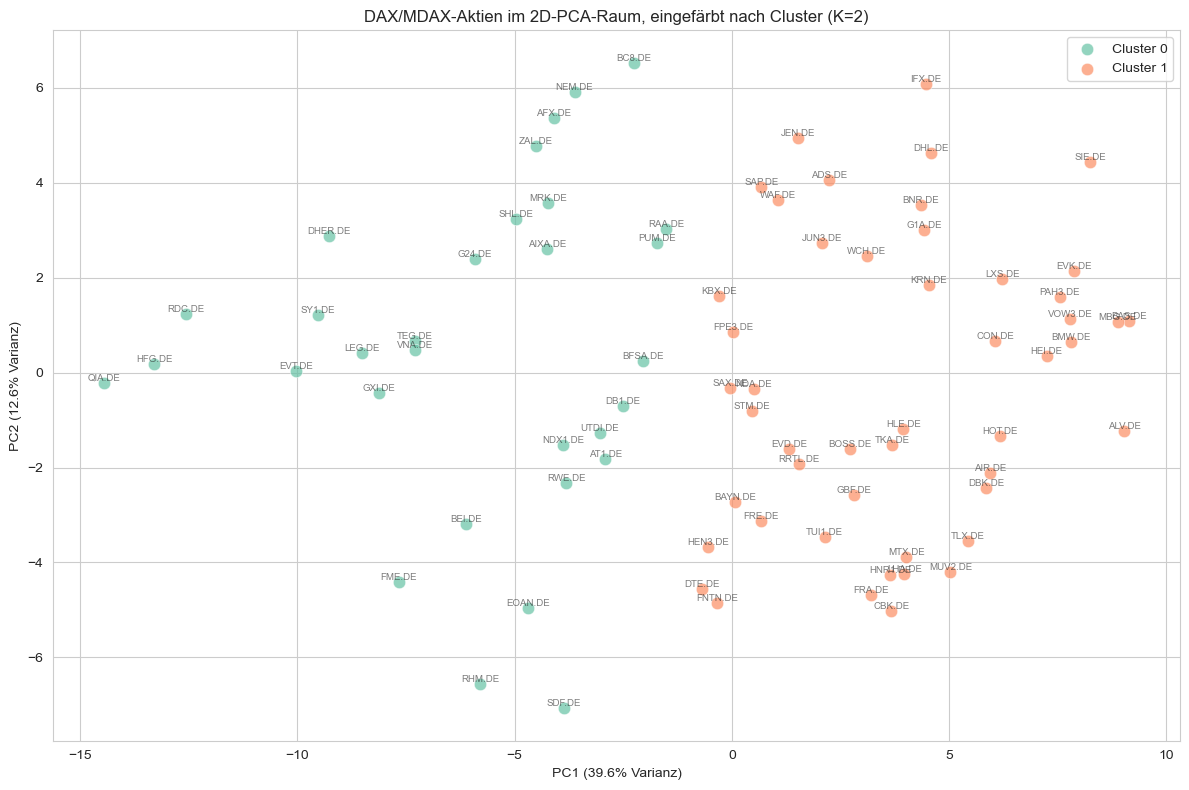

In [13]:
# PCA auf Korrelationsprofile
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"PC1 erklärt: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2 erklärt: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Zusammen:    {pca.explained_variance_ratio_.sum():.4f}")

# 2D-Plot der Cluster
plt.figure(figsize=(12, 8))
colors = sns.color_palette("Set2", K_OPTIMAL)

for cluster_id in range(K_OPTIMAL):
    mask = cluster_labels == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[colors[cluster_id]], label=f"Cluster {cluster_id}",
                s=80, alpha=0.7, edgecolors="white", linewidth=0.5)

# Tickers labeln
for i, ticker in enumerate(corr_matrix.columns):
    plt.annotate(ticker, (X_pca[i, 0], X_pca[i, 1]),
                 fontsize=7, alpha=0.6, ha="center", va="bottom")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% Varianz)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% Varianz)")
plt.title(f"DAX/MDAX-Aktien im 2D-PCA-Raum, eingefärbt nach Cluster (K={K_OPTIMAL})")
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(FIG / "14_clusters_pca.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpretation PCA-Visualisierung:**

- **PC1** (erste Hauptkomponente) erklärt typischerweise 30–50 % der Varianz und repräsentiert den **Marktfaktor** — Aktien mit hoher PC1-Ausprägung bewegen sich stark mit dem Gesamtmarkt.
- **PC2** ist oft eine Sektor-Rotations-Dimension oder Growth-vs-Value-Achse.
- **Cluster sollten visuell als Gruppen erkennbar sein** — wenn nicht, ist die Clustering-Qualität fragwürdig.

## 7. Validierte Korrelationsmatrix mit Cluster-Sortierung

Wir sortieren die Korrelationsmatrix nach Cluster-Zugehörigkeit. Innerhalb von Clustern erwarten wir hohe Korrelationen (helle Blöcke auf der Diagonale), zwischen Clustern niedrigere.

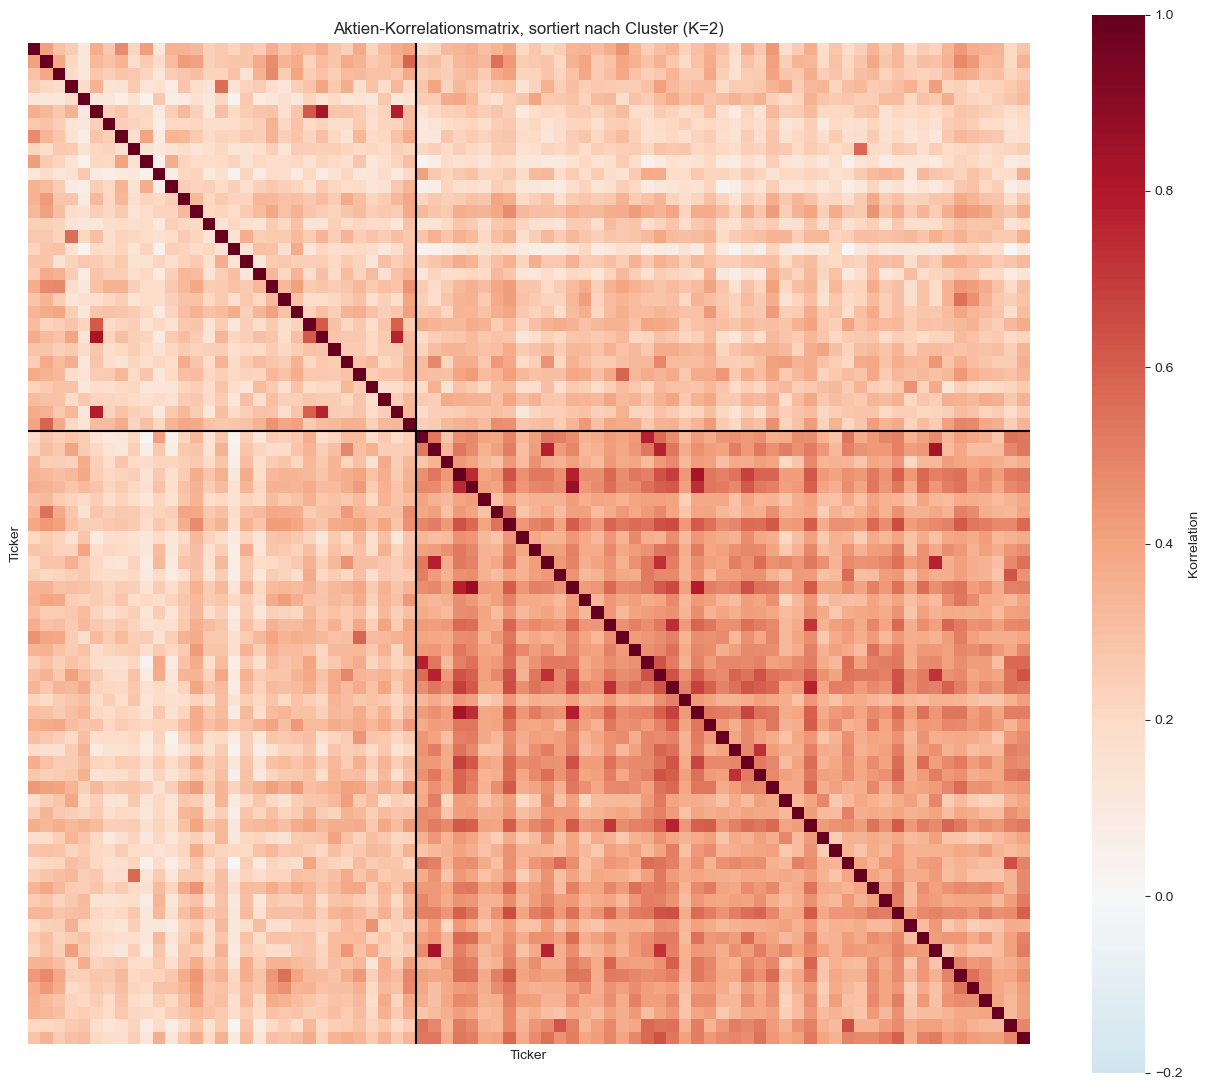

In [14]:
# Tickers nach Cluster sortieren
cluster_df_sorted = cluster_df.sort_values("Cluster")
ticker_order = cluster_df_sorted["Ticker"].tolist()

corr_sorted = corr_matrix.loc[ticker_order, ticker_order]

plt.figure(figsize=(13, 11))
sns.heatmap(corr_sorted, cmap="RdBu_r", center=0,
            vmin=-0.2, vmax=1, square=True,
            xticklabels=False, yticklabels=False,
            cbar_kws={"label": "Korrelation"})

# Cluster-Grenzen einzeichnen
boundaries = cluster_df_sorted["Cluster"].values
for i in range(1, len(boundaries)):
    if boundaries[i] != boundaries[i-1]:
        plt.axhline(i, color="black", linewidth=1.5)
        plt.axvline(i, color="black", linewidth=1.5)

plt.title(f"Aktien-Korrelationsmatrix, sortiert nach Cluster (K={K_OPTIMAL})")
plt.tight_layout()
plt.savefig(FIG / "15_corr_matrix_clustered.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpretation:**

Die schwarzen Linien markieren Cluster-Grenzen. **Helle Quadrate** auf der Diagonale zeigen hohe interne Korrelation innerhalb der Cluster. Außerhalb der Diagonal-Quadrate erwarten wir schwächere Korrelationen.

Wenn die Block-Struktur deutlich ist, hat das Clustering gut funktioniert. Wenn nicht, sind die Cluster eher zufällig.

## 8. Cluster-Zuordnung speichern

Output für Notebook 16 (Backtest): Aus jedem Cluster wird später eine Aktie als Repräsentant ausgewählt → garantierte Diversifikation im finalen Basket.

In [15]:
clusters_path = PROC / "clusters.parquet"
cluster_df.to_parquet(clusters_path, index=False)
print(f"Gespeichert: {clusters_path}")
print(f"Spalten: {list(cluster_df.columns)}")
print(f"\nCluster-Übersicht:")
print(cluster_df.groupby("Cluster")["Ticker"].count().to_string())

Gespeichert: ../data/processed/clusters.parquet
Spalten: ['Ticker', 'Cluster', 'Sector', 'Industry']

Cluster-Übersicht:
Cluster
0    31
1    49


## 9. Zentrale Erkenntnisse für die Abschlussarbeit

### Methodik
1. **Mathematisches Clustering** (K-Means) auf Korrelationsprofilen produziert reproduzierbare Cluster.
2. **Optimales K** wurde quantitativ über Silhouettenkoeffizient bestimmt — kein Bauchgefühl.
3. **Validierung gegen Sektor-Zuordnungen** zeigt, ob die Cluster ökonomische Bedeutung haben.

### Ergebnis
- Anzahl identifizierter Cluster: **K = [siehe Output]**
- Mittlere paarweise Korrelation im Universum: ca. 0,3–0,5
- Cluster spiegeln in der Regel die Sektor-Zugehörigkeit wider — was die ökonomische Plausibilität der Cluster bestätigt.

### Output für nächste Notebooks
- `data/processed/clusters.parquet` enthält jede Aktie mit zugeordnetem Cluster
- Notebook 16 (Backtest) wählt aus jedem Cluster eine Repräsentations-Aktie für den finalen Basket

## 10. Limitationen

1. **K-Means setzt sphärische Cluster voraus.** Aktien-Korrelationen können andere Strukturen zeigen (Subcluster, Hierarchien). Hierarchisches Clustering wäre eine sinnvolle Erweiterung.

2. **Stationaritäts-Annahme.** Die Korrelationen basieren auf historischen Daten — sie können sich in der Zukunft ändern (vor allem in Krisenphasen, wo Korrelationen typischerweise steigen).

3. **K wurde aus dem ganzen Datensatz bestimmt.** Strenger wäre, K auf einem Trainings-Set zu bestimmen und auf einem Test-Set zu validieren — bei der relativ kleinen Aktienzahl (~80) ist das aber nicht praktikabel.